In [ ]:
library(here)
suppressPackageStartupMessages(library(brms))
suppressPackageStartupMessages(library(tidyverse))
library(tidybayes)

options(box.path = here())
box::use(r / load)

r_out <- here("reports", "figures")
model_path <- here("data", "models", "hurdle")

PLOT_WIDTH <- 9
PLOT_HEIGHT <- 6

box::reload(load)


here() starts at /Users/lukas/git/ytpop

Attaching package: ‘tidybayes’

The following objects are masked from ‘package:brms’:

    dstudent_t, pstudent_t, qstudent_t, rstudent_t



In [ ]:
# library(dplyr)
# library(purrr)
# library(stringr)
# library(brms)
# library(tibble)
# library(here)

# helper: read one .rds and return tidy draws for the coef we're interested in
read_draws <- function(path, type) {
    file <- basename(path)
    party <- tools::file_path_sans_ext(file)

    fit <- readRDS(path)

    # grab all b_* (count) and b_hu_* (hurdle) coefficients
    draws <- gather_draws(
        fit,
        `b_.*`, # count part
        `b_hu_.*`, # hurdle part
        regex = TRUE
    ) %>%
        mutate(
            party = party,
            type  = type
        )

    draws
}

# collect draws from both folders
paths_elite <- dir(here(model_path, "views_elite"), full.names = TRUE)
paths_pplcentr <- dir(here(model_path, "views_pplcentr"), full.names = TRUE)

draws_elite <- map_dfr(paths_elite, read_draws, type = "elite")
draws_pplcentr <- map_dfr(paths_pplcentr, read_draws, type = "pplcentr")

draws_all <- bind_rows(draws_elite, draws_pplcentr)


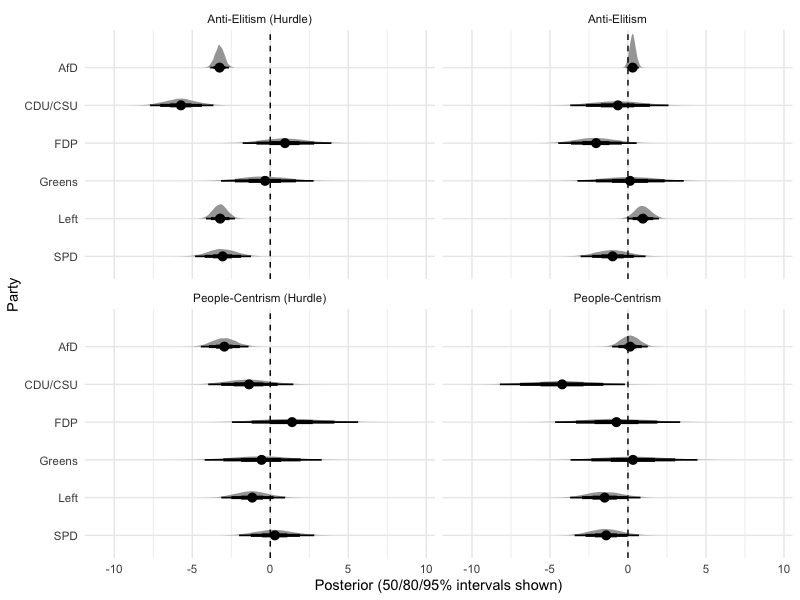

In [ ]:
lab_map <- c(
  b_hu_elite    = "Anti-Elitism (Hurdle)",
  b_elite       = "Anti-Elitism",
  b_hu_pplcentr = "People-Centrism (Hurdle)",
  b_pplcentr    = "People-Centrism"
)

plot_df <- draws_all |>
  filter(.variable %in% names(lab_map)) |>
  mutate(
    term = factor(
      lab_map[.variable],
      levels = lab_map
    ),
    party = factor(party, levels = sort(unique(party), decreasing = TRUE)),
    party = recode(
      party,
      "spd" = "SPD",
      "left" = "Left",
      "greens" = "Greens",
      "fdp" = "FDP",
      "cdu_csu" = "CDU/CSU",
      "afd" = "AfD",
    )
  )


plot <- ggplot(plot_df, aes(x = .value, y = party)) +
  stat_halfeye(.width = c(.5, .8, .95), point_interval = mean_qi) +
  geom_vline(xintercept = 0, linetype = "dashed") +
  theme_minimal() +
  facet_wrap(~term, ncol = 2, scales = "fixed") +
  labs(
    x = "Posterior (50/80/95% intervals shown)",
    y = "Party"
  )

plot


In [ ]:
path <- here("reports", "figures", "hurdle_model_coefficients.svg")
if (file.exists(path)) file.remove(path)
ggsave(path, plot, width = PLOT_WIDTH, height = PLOT_HEIGHT)
